## 1장 1강 : LLM 애플리케이션의 입력과 출력 구조

Langchain 프레임워크
- "추상화"
  - 정해지지 않은
  - 공통적인 <-- (다양한 LLM이 있지만 공통적인 틀에 맞춰서 인터페이스를 적용함.)

### 의존 패키지 설치
```
uv add ipykernel langchain langchain-core langchain-ollama python-dotenv
```

### 3. LCEL 파이프라인 실습

#### 3.1 환경 변수 로드 및 패키지 불러오기

In [5]:
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate

#### 3.2 ChatPromptTemplate으로 입력 템플릿 조립하기

시스템 역할과 사용자 질문 변수({user_question})를 담은 템플릿 생성<br>
system: "당신은 컴퓨터 기초 개념을 일상적인 사물에 빗대어 설명하는 교육 전문가입니다. 2문장 이내로 친절하게 설명하세요."<br>
user: "{user_question}"

In [8]:
# 시스템 메시지, SystemMessage(...): 역할, 상황, 제한 조건, 예시 
# user, HumanMessage(...): 사용자의 정의
# assistant, AIMessage(...): AI의 답변

prompt_template = ChatPromptTemplate.from_messages([
    ("system", "당신은 컴퓨터 기초 개념을 일상적인 사물에 빗대어 설명하는 교육 전문가입니다. 2문장 이내로 친절하게 설명하세요."), # system message 입력
    ("user", "{user_question}") # user_question은 user가 넣는 값에 따라 달라지므로, "{변수}"로 치환
])

템플릿에 텍스트용 질문 데이터를 주입하여 결과를 확인

user_question: "프로그래밍에서 '변수'가 무엇인가요?"

In [11]:
sample_prompt = prompt_template.invoke({
    "user_question": "프로그래밍에서 '변수'가 무엇인가요?"
})

sample_prompt

ChatPromptValue(messages=[SystemMessage(content='당신은 컴퓨터 기초 개념을 일상적인 사물에 빗대어 설명하는 교육 전문가입니다. 2문장 이내로 친절하게 설명하세요.', additional_kwargs={}, response_metadata={}), HumanMessage(content="프로그래밍에서 '변수'가 무엇인가요?", additional_kwargs={}, response_metadata={})])

#### 3.3 ChatOllama로 mistral 모델 호출하기

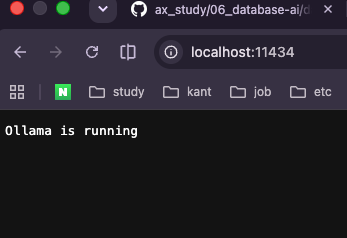
- Ollama status check

ChatOllama 모델 인스턴스 생성

In [15]:
model = ChatOllama(
    model="mistral",
    base_url="http://localhost:11434" # Ollama server address
)

model

ChatOllama(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, model='mistral', base_url='http://localhost:11434')

앞서 만든 sample_prompt를 모델에 직접 전달하여 실행

In [16]:
response = model.invoke(sample_prompt)
response

AIMessage(content=' 변수는 프로그래밍 중에 데이터를 저장하고 사용하기 위한 상자라고 생각하면 됩니다. 이 상자에 데이터를 저장하면, 이름 뒤의 상자(변수)로 언제든지 데이터에 접근할 수 있습니다. 예를 들어, "우리 집의 주소"는 우리가 집을 찾을 때 필요한 정보라 할 수 있습니다. 이렇게 우리는 집의 주소를 저장할 변수를 만들 수 있습니다.', additional_kwargs={}, response_metadata={'model': 'mistral', 'created_at': '2026-09-09T05:45:58.136975Z', 'done': True, 'done_reason': 'stop', 'total_duration': 10676815208, 'load_duration': 2965505542, 'prompt_eval_count': 106, 'prompt_eval_duration': 685817000, 'eval_count': 188, 'eval_duration': 7006748000, 'logprobs': None, 'model_name': 'mistral', 'model_provider': 'ollama'}, id='lc_run--01a084b3-70b8-7780-9f98-18d132e74707-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 106, 'output_tokens': 188, 'total_tokens': 294})

#### 3.4 StrOutputParser로 순수 텍스트만 추출하기

문자열 출력 파서 생성

In [19]:
from langchain_core.output_parsers import StrOutputParser

parser = StrOutputParser()


raw_response 객체에서 순수 텍스트만 추출

In [22]:
text = parser.invoke(response)
text

' 변수는 프로그래밍 중에 데이터를 저장하고 사용하기 위한 상자라고 생각하면 됩니다. 이 상자에 데이터를 저장하면, 이름 뒤의 상자(변수)로 언제든지 데이터에 접근할 수 있습니다. 예를 들어, "우리 집의 주소"는 우리가 집을 찾을 때 필요한 정보라 할 수 있습니다. 이렇게 우리는 집의 주소를 저장할 변수를 만들 수 있습니다.'

#### 3.5 LCEL 파이프(|) 연산자로 완전한 체인 결합 및 실행하기

파이프(|) 연산자를 사용해 3개 컴포넌트를 하나의 파이프라인으로 연결

In [23]:
chain = prompt_template | model | parser

새로운 질문으로 파이프라인 전체 실행

In [24]:
chain.invoke({
    "user_question": "프로그래밍 언어에서 클래스(Class)에 대해 알기 쉬운 비유를 통해 설명해줘" # 치환되는 부분 설정
})

" 클래스(Class)는 객체의 틀(Blueprint)이라고 생각하면 됩니다. 예를 들어, 자동차를 생산하는 공장은 각 자동차의 기본적인 형태와 특징을 가지고 있는 '자동차 틀'을 사용하여 각각의 자동차를 생산합니다. 이와 마찬가지로, 프로그래밍 언어에서는 클래스를 사용하여 특정 행위(함수)와 특성(변수)을 가지고 있는 객체를 생성합니다."

### 4. 프롬프트 엔지니어링
#### 4.1 프롬프트 엔지니어링의 3대 핵심 역할
- 목표 명확화
- 제약 조건 부여
- 출력 규격 표준화

#### 4.2 AI 성능 확장 4단계 비교
- Prompt Engineering
- RAG (검색 증강 생성)
- Fine-tuning (미세 조정)
- AI Agent (에이전트)